In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # 'n' = nano, the smallest/fastest version

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/drive/MyDrive/SpatialAI/data/raw_images/frame_0010.jpg: 640x384 1 laptop, 1 book, 359.4ms
Speed: 13.0ms preprocess, 359.4ms inference, 39.3ms postprocess per image at shape (1, 3, 640, 384)


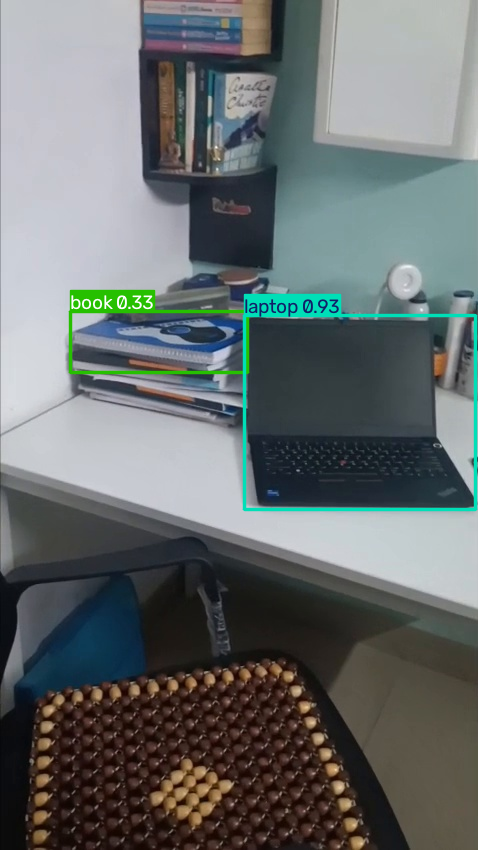

In [6]:
import os

image_folder = '/content/drive/MyDrive/SpatialAI/data/raw_images'
test_image = os.path.join(image_folder, 'frame_0010.jpg')

results = model(test_image)
results[0].show()

In [7]:
import json

detections_output = '/content/drive/MyDrive/SpatialAI/outputs/detections'
os.makedirs(detections_output, exist_ok=True)
os.makedirs(os.path.join(detections_output, 'annotated_images'), exist_ok=True)

all_detections = {}

image_files = sorted(os.listdir(image_folder))

for img_name in image_files:
    img_path = os.path.join(image_folder, img_name)
    results = model(img_path, verbose=False)

    # Save annotated image (with boxes drawn) for visual review
    annotated = results[0].plot()  # returns image array with boxes drawn
    save_path = os.path.join(detections_output, 'annotated_images', img_name)
    import cv2
    cv2.imwrite(save_path, annotated)

    # Save raw detection data (class, confidence, box coordinates)
    frame_detections = []
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()  # [x1, y1, x2, y2] box corners

        frame_detections.append({
            'class': class_name,
            'confidence': round(confidence, 3),
            'box': [round(c, 1) for c in xyxy]
        })

    all_detections[img_name] = frame_detections

# Save all detections to one JSON file
with open(os.path.join(detections_output, 'detections.json'), 'w') as f:
    json.dump(all_detections, f, indent=2)

print(f"Processed {len(image_files)} frames.")
print(f"Results saved to {detections_output}")

Processed 71 frames.
Results saved to /content/drive/MyDrive/SpatialAI/outputs/detections


In [8]:
model = YOLO('yolov8m.pt')  # 'm' = medium, more accurate, still no training needed

In [9]:
all_detections = {}

CONFIDENCE_THRESHOLD = 0.4  # discard anything below this

for img_name in image_files:
    img_path = os.path.join(image_folder, img_name)
    results = model(img_path, verbose=False, conf=CONFIDENCE_THRESHOLD)  # <- threshold applied here directly

    annotated = results[0].plot()
    save_path = os.path.join(detections_output, 'annotated_images', img_name)
    cv2.imwrite(save_path, annotated)

    frame_detections = []
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()

        frame_detections.append({
            'class': class_name,
            'confidence': round(confidence, 3),
            'box': [round(c, 1) for c in xyxy]
        })

    all_detections[img_name] = frame_detections

with open(os.path.join(detections_output, 'detections.json'), 'w') as f:
    json.dump(all_detections, f, indent=2)

print(f"Processed {len(image_files)} frames with yolov8m at conf >= {CONFIDENCE_THRESHOLD}")

Processed 71 frames with yolov8m at conf >= 0.4
